# Analisis explotario del dataset historico de Customer Churn

En este notebook tenemos el objetivo de analizar las dimenciones, tipos de datos, valores faltantes, la distribuccion del target, la calidad de los datos y las variables mas relevantes.

In [ ]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from source.datos.cargar_datos import cargar_datos_crudos, TARGET_COLUMN

df = cargar_datos_crudos("../data/raw/customer_churn_historical.csv")
df.shape

(7043, 21)

# Exploracion de tipos de datos.

In [2]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,6684-LWVH,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.170098,0.375746,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,35.168394,18.901478,0.0,20.0,35.0,51.0,72.0
PhoneService,7043,2,Yes,6368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3203,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Valores faltantes

`TotalCharges` presenta faltantes. Se corrigen en el pipiline de preprocesamiento. 

In [4]:
missing = df.isna().sum()
missing[missing > 0]

TotalCharges    26
dtype: int64

# Distribuccion del target

El target está **desbalanceado** (~26% Churn=Yes). Esto justifica:
- Usar `class_weight='balanced'` en los modelos.
- Estratificar el split train/test.
- No usar Accuracy como métrica principal de selección.

Churn
No     0.736334
Yes    0.263666
Name: proportion, dtype: float64


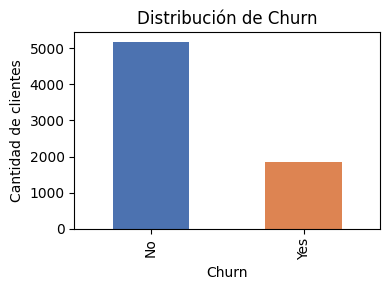

In [5]:
churn_rate = df[TARGET_COLUMN].value_counts(normalize=True)
print(churn_rate)

fig, ax = plt.subplots(figsize=(4,3))
df[TARGET_COLUMN].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Distribución de Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

# Variables relevantes vs Churn

Exploramos algunas variables con hipótesis de negocio clara:
- `Contract`: se espera que contratos mes a mes tengan más churn (menor "lock-in").
- `tenure`: se espera que clientes nuevos abandonen más.
- `MonthlyCharges`: se espera que cargos más altos se asocien a más churn.

In [6]:
pd.crosstab(df["Contract"], df[TARGET_COLUMN], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.612700,0.387300
One year,0.850264,0.149736
Two year,0.910256,0.089744


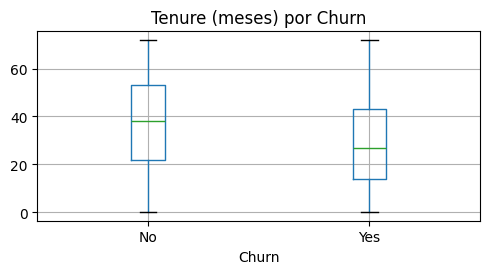

In [7]:
fig, ax = plt.subplots(figsize=(5,3))
df.boxplot(column="tenure", by=TARGET_COLUMN, ax=ax)
ax.set_title("Tenure (meses) por Churn")
plt.suptitle("")
plt.tight_layout()
plt.show()

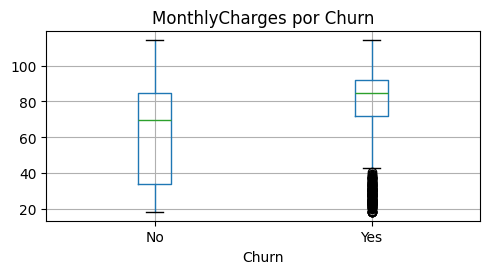

In [8]:
fig, ax = plt.subplots(figsize=(5,3))
df.boxplot(column="MonthlyCharges", by=TARGET_COLUMN, ax=ax)
ax.set_title("MonthlyCharges por Churn")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Calidad de datos

Se encontraron los siguientes problemas:

1. `TotalCharges` viene tipada como texto en el CSV original y tiene
   valores faltantes/espacios en blanco -> se resuelve con
   `pd.to_numeric(errors="coerce")` en `load_data.py`.
2. `customerID` es un identificador único, no debe usarse como
   predictor.
3. Varias categóricas usan la categoría `"No internet service"` /
   `"No phone service"` en lugar de `NaN` — son informativas y se
   codifican tal cual con OneHotEncoder, no se tratan como faltantes.
4. El target está desbalanceado (~26% positivos): decisión de
   modelado (class_weight balanceado) y de evaluación (no usar
   Accuracy sola).

# Conclusión del analisis.

El dataset es apto para realizar una clasificación binaria supervisada. 
Los principales retos son: Corregir el desbalanceo de clases, el tipado incorrecto de `TotalCharges` y alta cardinalidad combinada en variables categóricas de servicios (dependientes entre sí, ej. `OnlineSecurity` depende de tener `InternetService`).